In [60]:
# Базовые библиотеки
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pandas as pd

# PyTorch и PyTorch Lightning
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
from torchvision import transforms, datasets
import pytorch_lightning as pl
from pytorch_lightning import Trainer, seed_everything
from pytorch_lightning.loggers import CSVLogger
import torchmetrics

# ML метрики и тюнинг
from sklearn.metrics import confusion_matrix, classification_report
import optuna

# Настройки для reproducibility и скорости
seed_everything(42)
torch.backends.cudnn.benchmark = True
warnings.filterwarnings('ignore')

Seed set to 42


**Цель:** Изучение архитектуры CNN, методов оптимизации и трансферного обучения.



## Теоретические сведения о сверточных нейронных сетях
Сверточные нейронные сети (CNN) используют сверточные слои, в которых набор обучаемых фильтров (ядер) скользит по входному изображению. Во время прямого прохода каждое ядро свертывается по ширине и высоте входного тензора, вычисляя скалярное произведение между элементами фильтра и входа и создавая двумерную карту активаций. Стекинг карт активаций разных фильтров по глубинной оси формирует выходной объём слоя, а использование одного и того же набора параметров для всех позиций уменьшает число свободных параметров (это называется разделением параметров).

Размер выходного тензора сверточного слоя определяется тремя гиперпараметрами: глубиной (число фильтров), шагом (stride) и паддингом (padding). Шаг задаёт, на сколько пикселей смещается ядро при сканировании входа; если шаг равен 1, фильтр перемещается по одному пикселю и выходной тензор имеет большие размеры. Паддинг дополняет вход нулями по краям, позволяя управлять размером выхода и, например, сохранять пространственные размеры входа.

После сверточного слоя часто используется слой пулинга для уменьшения размерности и повышения устойчивости к сдвигам. Пулинг комбинирует значения на локальном участке карты признаков; наиболее популярны максимальный пулинг, выбирающий максимальное значение, и усредняющий пулинг, вычисляющий среднее на участке.

Транспонированная свёртка (иногда называемая «deconvolution») служит для повышения разрешения карты признаков. В отличие от обычной свёртки, где ядро скользит по входу, транспонированная свёртка «разворачивает» вход: входной тензор скользит по ядру, что приводит к выходу большего размера. Эта операция используется для генерации изображений, супер‑разрешения и сегментации. Размер выхода зависит от шага и паддинга: для ядра размера \(K_h	imes K_w\), входа \(I_h	imes I_w\), шага \(s_h, s_w\) и паддинга \(p\) высота и ширина выхода вычисляются как \(O_h = (I_h - 1)s_h + K_h - 2p\) и \(O_w = (I_w - 1)s_w + K_w - 2p\).

## Задание 1. Реализация функций свёртки и пулинга
Необходимо написать функцию `conv2d`, которая применяет свёртку к изображению с заданным ядром (`kernel`), шагом (`stride`) и паддингом (`padding`). В этой же задаче реализуйте функции `max_pool2d` и `avg_pool2d` с заданным размером окна (`pool_size`) и шагом (`stride`). Используйте паддинг `'valid'` или `'same'` либо укажите целое количество элементов для добавления по краям.

In [61]:
def conv2d(image: np.ndarray, kernel: np.ndarray, stride: int = 1, padding: str = 'valid') -> np.ndarray:
    h_k, w_k = kernel.shape
    h_i, w_i = image.shape
    
    if padding == 'same':
        # Математически точный расчет паддинга для same, если stride=1
        p_h = ((h_i - 1) * stride + h_k - h_i) // 2
        p_w = ((w_i - 1) * stride + w_k - w_i) // 2
    elif padding == 'valid':
        p_h, p_w = 0, 0
    elif isinstance(padding, int):
        p_h, p_w = padding, padding
    else:
        raise ValueError("padding must be 'valid', 'same' or an int")

    if p_h > 0 or p_w > 0:
        image = np.pad(image, ((p_h, p_h), (p_w, p_w)), mode='constant')

    h_p, w_p = image.shape
    h_o = (h_p - h_k) // stride + 1
    w_o = (w_p - w_k) // stride + 1
    
    out = np.zeros((h_o, w_o))
    for i in range(h_o):
        for j in range(w_o):
            w = image[i*stride : i*stride+h_k, j*stride : j*stride+w_k]
            out[i, j] = np.sum(w * kernel)
    return out

# Пример использования
image = np.random.rand(5, 5)
kernel = np.array([[1, 0, -1], [1, 0, -1], [1, 0, -1]])
result = conv2d(image, kernel, stride=2, padding="valid")
display(result)
print(result.shape)  # Ожидается (3, 3)

array([[-1.87949359,  1.38469654],
       [-0.83350182,  0.72021963]])

(2, 2)


In [62]:
def max_pool2d(image, pool_size=2, stride=2, padding = "valid"):
    p_h, p_w = pool_size, pool_size

    if padding == 'same':
        pad_h = (p_h - 1) // 2
        pad_w = (p_w - 1) // 2
    elif padding == 'valid':
        pad_h, pad_w = 0, 0
    else:
        raise ValueError("padding must be 'valid' or 'same'")

    if pad_h > 0 or pad_w > 0:
        image = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant')

    h_p, w_p = image.shape
    
    h_o = (h_p - p_h) // stride + 1
    w_o = (w_p - p_w) // stride + 1
    
    out = np.zeros((h_o, w_o))

    for i in range(h_o):
        for j in range(w_o):
            r_s = i * stride
            r_e = r_s + p_h
            c_s = j * stride
            c_e = c_s + p_w
            w = image[r_s:r_e, c_s:c_e]
            out[i, j] = np.max(w)
            
    return out

def avg_pool2d(image, pool_size=2, stride=1, padding='valid'):
    h_i, w_i = image.shape
    p_h, p_w = pool_size, pool_size

    if padding == 'same':
        pad_h = (p_h - 1) // 2
        pad_w = (p_w - 1) // 2
    elif padding == 'valid':
        pad_h, pad_w = 0, 0
    else:
        raise ValueError("padding must be 'valid' or 'same'")
        
    if pad_h > 0 or pad_w > 0:
        image = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant')

    h_p, w_p = image.shape
    
    h_o = (h_p - p_h) // stride + 1
    w_o = (w_p - p_w) // stride + 1
    
    out = np.zeros((h_o, w_o))

    for i in range(h_o):
        for j in range(w_o):
            r_s = i * stride
            r_e = r_s + p_h
            c_s = j * stride
            c_e = c_s + p_w
            w = image[r_s:r_e, c_s:c_e]
            out[i, j] = np.mean(w)
            
    return out

image = np.random.rand(5, 5)
kernel = np.array([[1, 0, -1], [1, 0, -1], [1, 0, -1]])
convolve = conv2d(image, kernel, stride=1, padding='valid')
print(convolve)
pooled = avg_pool2d(convolve, pool_size=2, stride=1)
pooled

[[ 1.52416002 -1.55072146 -0.77527679]
 [ 1.34086821 -1.57212416 -1.46745228]
 [ 0.94082921 -1.02876195 -0.23165827]]


array([[-0.06445435, -1.34139367],
       [-0.07979717, -1.07499917]])

In [63]:
pooled = max_pool2d(convolve, pool_size=2, stride=1)
pooled

array([[ 1.52416002, -0.77527679],
       [ 1.34086821, -0.23165827]])

In [64]:
pooled = max_pool2d(image, stride=1)
pooled

array([[0.78517596, 0.51423444, 0.94888554, 0.96563203],
       [0.80839735, 0.30461377, 0.94888554, 0.96563203],
       [0.80839735, 0.49517691, 0.9093204 , 0.9093204 ],
       [0.66252228, 0.52006802, 0.9093204 , 0.9093204 ]])

## Задание 2. Транспонированная свёртка 1D
Напишите функцию `transposed_conv1d` (или аналогично названную), которая реализует транспонированную (обратную) свёртку для одномерного сигнала. Функция должна принимать входной массив, ядро, шаг (`stride`, по умолчанию 1) и паддинг (`padding`, по умолчанию 0). Вывод функции должен иметь длину \((n-1) 	× stride + k - 2 	× padding\), где \(n\) — длина входа, а \(k\) — длина ядра.

In [65]:
def transposed_conv1d(x, kernel, stride=1, padding=0):
    """
    Реализует транспонированную 1D свёртку (также известную как 'полную' свёртку) для одномерного массива.
    Параметры:
    x : np.ndarray — входной 1D сигнал.
    kernel : np.ndarray — ядро свёртки.
    stride : int — шаг между элементами входа.
    padding : int — количество элементов, удаляемых с края после свёртки.
    """
    n = len(x)
    x_up = np.zeros((n - 1) * stride + 1)
    x_up[::stride] = x
    
    res = np.convolve(x_up, kernel, mode='full')
    
    if padding > 0:
        res = res[padding:-padding]
        
    return res

# Пример использования
x = np.array([1, 2, 3, 4])
k = np.array([1, 0, -1])
print(transposed_conv1d(x, k))

[ 1.  2.  2.  2. -3. -4.]


## Задание 3. Транспонированная свёртка 2D
Реализуйте функцию `transposed_conv2d`, которая выполняет транспонированную свёртку для двумерного изображения. Функция принимает входной массив, ядро, шаг (`stride`, целое или кортеж), паддинг (`padding`) и возвращает выход размером \(((H-1) 	imes stride_h + K_h - 2	imes padding), ((W-1) 	imes stride_w + K_w - 2	imes padding)\).

In [66]:
def transposed_conv2d(x, kernel, stride=1, padding=0):
    """
    Реализует транспонированную 2D свёртку для изображений.
    Параметры:
    x : np.ndarray — входной 2D массив.
    kernel : np.ndarray — ядро свёртки (2D).
    stride : int или tuple — шаг по вертикали и горизонтали.
    padding : int или tuple — паддинг, количество удаляемых строк/столбцов с краёв.
    """
    if isinstance(stride, int):
        s_h = stride
        s_w = stride
    else:
        s_h, s_w = stride

    if isinstance(padding, int):
        p_h = padding
        p_w = padding
    else:
        p_h, p_w = padding

    h_x, w_x = x.shape
    h_up = (h_x - 1) * s_h + 1
    w_up = (w_x - 1) * s_w + 1
    x_up = np.zeros((h_up, w_up))
    x_up[::s_h, ::s_w] = x
    
    res = conv2d(x_up, kernel)
    
    h_start = p_h
    h_end = res.shape[0] - p_h
    w_start = p_w
    w_end = res.shape[1] - p_w
    
    return res[h_start:h_end, w_start:w_end]

# Пример использования
image = np.array([[1, 2], [3, 4]])
kernel = np.array([[0, 1], [2, 3]])
print(transposed_conv2d(image, kernel))

[[20.]]


## Задание 4. Класс трёхслойной сверточной сети с пулингом и нормализацией
Создайте класс `ThreeLayerConvNet`, реализующий простую сверточную сеть из трёх сверточных слоёв. Каждый свёрточный слой должен использовать функцию `conv2d` (реализованную в задании 1), за ним применяется функция активации (например, ReLU), слой пулинга (`max_pool2d` или `avg_pool2d`) и нормализация (например, Batch Normalization на numpy). Класс должен предоставлять метод `forward(x)`, принимающий входной двумерный массив и возвращающий выход сети.

In [67]:
class ThreeLayerConvNet:
    def __init__(self, kernels, strides=1, paddings='valid', pool_size=2, pool_stride=2):
        self.kernels = kernels
        self.strides = [strides]*3 if isinstance(strides, int) else strides
        self.paddings = [paddings]*3 if isinstance(paddings, (int, str)) else paddings
        self.pool_size = pool_size
        self.pool_stride = pool_stride
        
    def batch_norm(self, x: np.ndarray, eps: float = 1e-5) -> np.ndarray:
        mean = np.mean(x)
        var = np.var(x)
        return (x - mean) / np.sqrt(var + eps)
        
    def forward(self, x: np.ndarray) -> np.ndarray:
        out = x
        for i in range(3):
            out = conv2d(out, self.kernels[i], stride=self.strides[i], padding=self.paddings[i])
            out = np.maximum(0, out) # ReLU
            out = max_pool2d(out, pool_size=self.pool_size, stride=self.pool_stride)
            out = self.batch_norm(out)
        return out

kernels =[np.random.randn(3,3), np.random.randn(3,3), np.random.randn(3,3)]
model = ThreeLayerConvNet(kernels, strides=1, paddings='same')
image = np.random.rand(32, 32)
output = model.forward(image)
print("Output shape after 3 Conv-Pool layers:", output.shape)

Output shape after 3 Conv-Pool layers: (4, 4)


# Лабораторная часть

## Задание 5. Архитектура LeNet для CIFAR-10
Реализовать LeNet-5 и обучить на CIFAR-10.

In [68]:
class CIFAR10DataModule(pl.LightningDataModule):
    def __init__(self, batch_size=64):
        super().__init__()
        self.batch_size = batch_size
        self.transform = transforms.Compose([
            transforms.ToTensor(),
            # Нормализация (mean, std) каналов RGB для CIFAR-10
            transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
        ])

    def prepare_data(self):
        datasets.CIFAR10(root='./data', train=True, download=True)
        datasets.CIFAR10(root='./data', train=False, download=True)

    def setup(self, stage=None):
        if stage == 'fit' or stage is None:
            cifar_full = datasets.CIFAR10(root='./data', train=True, transform=self.transform)
            self.cifar_train, self.cifar_val = random_split(cifar_full, [45000, 5000])
        if stage == 'test' or stage is None:
            self.cifar_test = datasets.CIFAR10(root='./data', train=False, transform=self.transform)

    def train_dataloader(self):
        return DataLoader(self.cifar_train, batch_size=self.batch_size, shuffle=True, num_workers=7, persistent_workers=True)

    def val_dataloader(self):
        return DataLoader(self.cifar_val, batch_size=self.batch_size, num_workers=7, persistent_workers=True)

    def test_dataloader(self):
        return DataLoader(self.cifar_test, batch_size=self.batch_size, num_workers=7, persistent_workers=True)

class LeNet5Lightning(pl.LightningModule):
    def __init__(self, activation_fn=nn.ReLU, use_batchnorm=False, use_dropout=False, lr=1e-3):
        super().__init__()
        self.save_hyperparameters()
        self.lr = lr
        
        self.use_batchnorm = use_batchnorm
        self.use_dropout = use_dropout
        self.act = activation_fn()
        
        # [Batch, 3, 32, 32] -> [Batch, 6, 28, 28]
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=6, kernel_size=5)
        self.bn1 = nn.BatchNorm2d(6) if use_batchnorm else nn.Identity()
        self.pool1 = nn.AvgPool2d(kernel_size=2, stride=2) # -> [Batch, 6, 14, 14]
        
        #[Batch, 6, 14, 14] ->[Batch, 16, 10, 10]
        self.conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5)
        self.bn2 = nn.BatchNorm2d(16) if use_batchnorm else nn.Identity()
        self.pool2 = nn.AvgPool2d(kernel_size=2, stride=2) # -> [Batch, 16, 5, 5]
        
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.drop1 = nn.Dropout(0.5) if use_dropout else nn.Identity()
        self.fc2 = nn.Linear(120, 84)
        self.drop2 = nn.Dropout(0.5) if use_dropout else nn.Identity()
        self.fc3 = nn.Linear(84, 10)
        
        # Метрики
        self.train_acc = torchmetrics.Accuracy(task="multiclass", num_classes=10)
        self.val_acc = torchmetrics.Accuracy(task="multiclass", num_classes=10)
        self.test_acc = torchmetrics.Accuracy(task="multiclass", num_classes=10)

    def forward(self, x):
        x = self.pool1(self.act(self.bn1(self.conv1(x))))
        x = self.pool2(self.act(self.bn2(self.conv2(x))))
        x = torch.flatten(x, 1) # Уплощаем: [Batch, 16, 5, 5] ->[Batch, 400]
        x = self.act(self.fc1(x))
        x = self.drop1(x)
        x = self.act(self.fc2(x))
        x = self.drop2(x)
        x = self.fc3(x)
        return x

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        self.train_acc(logits, y)
        self.log('train_loss', loss, prog_bar=True)
        self.log('train_acc', self.train_acc, on_step=False, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        self.val_acc(logits, y)
        self.log('val_loss', loss, prog_bar=True)
        self.log('val_acc', self.val_acc, prog_bar=True)

    def test_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        self.test_acc(logits, y)
        self.log('test_loss', loss)
        self.log('test_acc', self.test_acc)
        return logits, y

    def configure_optimizers(self):
        return optim.Adam(self.parameters(), lr=self.lr)

models=dict()

dm = CIFAR10DataModule(batch_size=128)
model_lenet = LeNet5Lightning(activation_fn=nn.ReLU)

trainer_lenet = Trainer(max_epochs=5, accelerator='auto', enable_progress_bar=True)
trainer_lenet.fit(model_lenet, datamodule=dm)
trainer_lenet.test(model_lenet, datamodule=dm)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name      ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ act       │ ReLU               │      0 │ train │     0 │
│ 1  │ conv1     │ Conv2d             │    456 │ train │     0 │
│ 2  │ bn1       │ Identity           │      0 │ train │     0 │
│ 3  │ pool1     │ AvgPool2d          │      0 │ train │     0 │
│ 4  │ conv2     │ Conv2d             │  2.4 K │ train │     0 │
│ 5  │ bn2       │ Identity           │      0 │ train │     0 │
│ 6  │ pool2     │ AvgPool2d          │      0 │ train │     0 │
│ 7  │ fc1       │ Linear             │ 48.1 K │ train │     0 │
│ 8  │ drop1     │ Identity           │      0 │ train │     0 │
│ 9  │ fc2       │ Linear             │ 10.2 K │ train │     0 │
│ 10 │ drop2     │ Identity           │      0 │ train │     0 │
│ 11 │ fc3       │ Linear             │    850 │ train │     0 │
│ 12 │ train_acc │ MulticlassAccuracy │      0 │ train │     0 │
│ 13 │ val_acc   │ MulticlassAccuracy │      0 │ train │     0 │
│ 14 │ test_acc  │ MulticlassAccuracy │      0 │ train │     0 │
└────┴───────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 62.0 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 62.0 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 15                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_epochs=5` reached.


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.5519999861717224     │
│         test_loss         │    1.2575372457504272     │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 1.2575372457504272, 'test_acc': 0.5519999861717224}]

## Задание 6. Добавление Dropout и BatchNorm
 Модифицировать LeNet, добавив Dropout и BatchNorm. Сравнить точность.

In [69]:
for use_batchnorm, use_dropout in [(i, j) for i in [True, False] for j in [True, False]]:
    name = 'LeNet-5 [ReLU]' + use_batchnorm*'[BatchNorm]' + use_dropout*'[DropOut]'
    print(name)
    model_lenet_advanced = LeNet5Lightning(activation_fn=nn.ReLU, use_batchnorm=use_batchnorm, use_dropout=use_dropout)
    trainer_advanced = Trainer(max_epochs=5, accelerator='auto', enable_progress_bar=True)
    trainer_advanced.fit(model_lenet_advanced, datamodule=dm)
    trainer_advanced.test(model_lenet_advanced, datamodule=dm)

    models[name] = model_lenet_advanced

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


LeNet-5 [ReLU][BatchNorm][DropOut]


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name      ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ act       │ ReLU               │      0 │ train │     0 │
│ 1  │ conv1     │ Conv2d             │    456 │ train │     0 │
│ 2  │ bn1       │ BatchNorm2d        │     12 │ train │     0 │
│ 3  │ pool1     │ AvgPool2d          │      0 │ train │     0 │
│ 4  │ conv2     │ Conv2d             │  2.4 K │ train │     0 │
│ 5  │ bn2       │ BatchNorm2d        │     32 │ train │     0 │
│ 6  │ pool2     │ AvgPool2d          │      0 │ train │     0 │
│ 7  │ fc1       │ Linear             │ 48.1 K │ train │     0 │
│ 8  │ drop1     │ Dropout            │      0 │ train │     0 │
│ 9  │ fc2       │ Linear             │ 10.2 K │ train │     0 │
│ 10 │ drop2     │ Dropout            │      0 │ train │     0 │
│ 11 │ fc3       │ Linear             │    850 │ train │     0 │
│ 12 │ train_acc │ MulticlassAccuracy │      0 │ train │     0 │
│ 13 │ val_acc   │ MulticlassAccuracy │      0 │ train │     0 │
│ 14 │ test_acc  │ MulticlassAccuracy │      0 │ train │     0 │
└────┴───────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 62.1 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 62.1 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 15                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

Output()

`Trainer.fit` stopped: `max_epochs=5` reached.


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │     0.545799970626831     │
│         test_loss         │    1.2728053331375122     │
└───────────────────────────┴───────────────────────────┘

## Задание 7. Трансферное обучение с VGG16 на CIFAR-10
Использовать предобученную VGG16, заменить классификатор и дообучить.

In [70]:

class VGG16TransferLightning(pl.LightningModule):
    def __init__(self, lr=1e-3):
        super().__init__()
        self.lr = lr
        
        self.vgg16 = torchvision.models.vgg16(weights=torchvision.models.VGG16_Weights.IMAGENET1K_V1)
        
        for param in self.vgg16.features.parameters():
            param.requires_grad = False

        num_features = self.vgg16.classifier[6].in_features
        self.vgg16.classifier[6] = nn.Linear(num_features, 10)
        
        self.train_acc = torchmetrics.Accuracy(task="multiclass", num_classes=10)
        self.val_acc = torchmetrics.Accuracy(task="multiclass", num_classes=10)
        self.test_acc = torchmetrics.Accuracy(task="multiclass", num_classes=10)

    def forward(self, x):
        #[Batch, 3, 32, 32]
        return self.vgg16(x) # -> [Batch, 10]

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        self.train_acc(logits, y)
        self.log('train_loss', loss)
        self.log('train_acc', self.train_acc, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        self.val_acc(logits, y)
        self.log('val_loss', loss, prog_bar=True)
        self.log('val_acc', self.val_acc, prog_bar=True)

    def test_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        self.test_acc(logits, y)
        self.log('test_acc', self.test_acc)
        return logits, y

    def configure_optimizers(self):
        return optim.Adam(self.vgg16.classifier.parameters(), lr=self.lr)

model_vgg = VGG16TransferLightning()
trainer_vgg = Trainer(max_epochs=5, accelerator='auto')
trainer_vgg.fit(model_vgg, datamodule=dm)
trainer_vgg.test(model_vgg, datamodule=dm)
models['VGG-16'] = model_vgg

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ vgg16     │ VGG                │  134 M │ train │     0 │
│ 1 │ train_acc │ MulticlassAccuracy │      0 │ train │     0 │
│ 2 │ val_acc   │ MulticlassAccuracy │      0 │ train │     0 │
│ 3 │ test_acc  │ MulticlassAccuracy │      0 │ train │     0 │
└───┴───────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 119 M                                                                                            
Non-trainable params: 14.7 M                                                                                       
Total params: 134 M                                                                                                
Total estimated model params size (MB): 537                                                                        
Modules in train mode: 45                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_epochs=5` reached.


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.6617000102996826     │
└───────────────────────────┴───────────────────────────┘

## Задание 8. Сравнение функций активации
 Обучить CNN из задания 5 с ReLU, Sigmoid, Tanh. Сравнить графики обучения.

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


Training with ReLU


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name      ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ act       │ ReLU               │      0 │ train │     0 │
│ 1  │ conv1     │ Conv2d             │    456 │ train │     0 │
│ 2  │ bn1       │ Identity           │      0 │ train │     0 │
│ 3  │ pool1     │ AvgPool2d          │      0 │ train │     0 │
│ 4  │ conv2     │ Conv2d             │  2.4 K │ train │     0 │
│ 5  │ bn2       │ Identity           │      0 │ train │     0 │
│ 6  │ pool2     │ AvgPool2d          │      0 │ train │     0 │
│ 7  │ fc1       │ Linear             │ 48.1 K │ train │     0 │
│ 8  │ drop1     │ Identity           │      0 │ train │     0 │
│ 9  │ fc2       │ Linear             │ 10.2 K │ train │     0 │
│ 10 │ drop2     │ Identity           │      0 │ train │     0 │
│ 11 │ fc3       │ Linear             │    850 │ train │     0 │
│ 12 │ train_acc │ MulticlassAccuracy │      0 │ train │     0 │
│ 13 │ val_acc   │ MulticlassAccuracy │      0 │ train │     0 │
│ 14 │ test_acc  │ MulticlassAccuracy │      0 │ train │     0 │
└────┴───────────┴────────────────────┴────────┴───────┴───────┘

...

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name      ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ act       │ Tanh               │      0 │ train │     0 │
│ 1  │ conv1     │ Conv2d             │    456 │ train │     0 │
│ 2  │ bn1       │ Identity           │      0 │ train │     0 │
│ 3  │ pool1     │ AvgPool2d          │      0 │ train │     0 │
│ 4  │ conv2     │ Conv2d             │  2.4 K │ train │     0 │
│ 5  │ bn2       │ Identity           │      0 │ train │     0 │
│ 6  │ pool2     │ AvgPool2d          │      0 │ train │     0 │
│ 7  │ fc1       │ Linear             │ 48.1 K │ train │     0 │
│ 8  │ drop1     │ Identity           │      0 │ train │     0 │
│ 9  │ fc2       │ Linear             │ 10.2 K │ train │     0 │
│ 10 │ drop2     │ Identity           │      0 │ train │     0 │
│ 11 │ fc3       │ Linear             │    850 │ train │     0 │
│ 12 │ train_acc │ MulticlassAccuracy │      0 │ train │     0 │
│ 13 │ val_acc   │ MulticlassAccuracy │      0 │ train │     0 │
│ 14 │ test_acc  │ MulticlassAccuracy │      0 │ train │     0 │
└────┴───────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 62.0 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 62.0 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 15                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

`Trainer.fit` stopped: `max_epochs=5` reached.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.5273000001907349     │
│         test_loss         │    1.3209292888641357     │
└───────────────────────────┴───────────────────────────┘

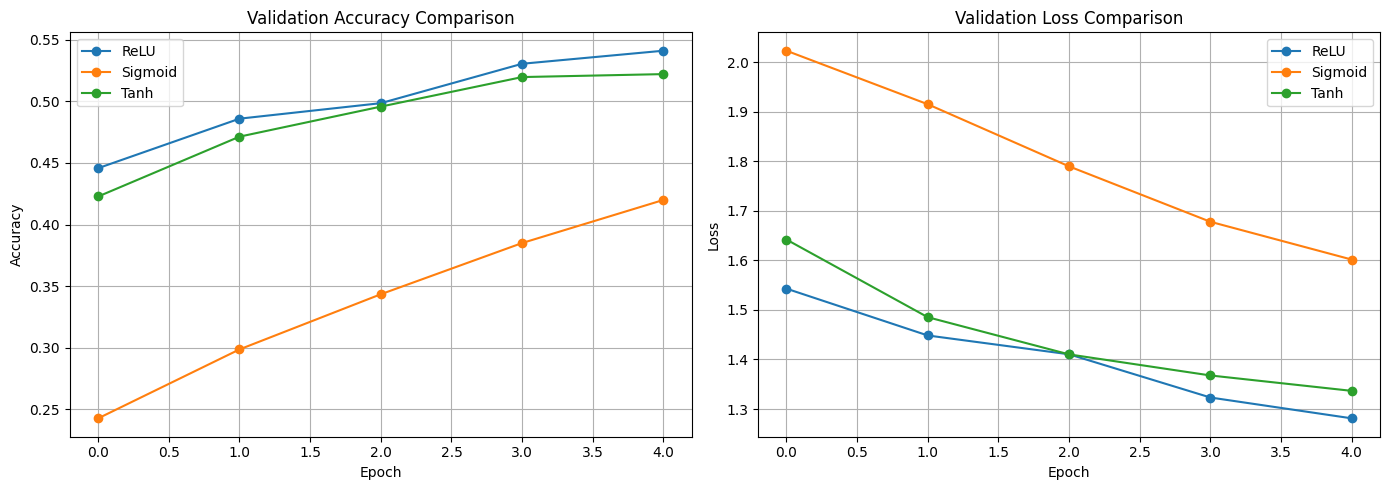

In [71]:
activations = {'ReLU': nn.ReLU, 'Sigmoid': nn.Sigmoid, 'Tanh': nn.Tanh}
histories = {}

for name, act_fn in activations.items():
    print(f"Training with {name}")
    model = LeNet5Lightning(activation_fn=act_fn)
    logger = CSVLogger("logs", name=name)
    trainer = Trainer(max_epochs=5, accelerator='auto', logger=logger, enable_progress_bar=False)
    trainer.fit(model, datamodule=dm)
    trainer.test(model, datamodule=dm)
    models['LeNet-5 '+f'[{name}]'] = model
    histories[name] = logger.experiment.metrics_file_path
    
plt.figure(figsize=(14, 5))

for name, log_path in histories.items():
    df = pd.read_csv(log_path)
    val_df = df[df['val_acc'].notna()]
    
    plt.subplot(1, 2, 1)
    plt.plot(val_df['epoch'], val_df['val_acc'], marker='o', label=name)
    
    plt.subplot(1, 2, 2)
    plt.plot(val_df['epoch'], val_df['val_loss'], marker='o', label=name)

plt.subplot(1, 2, 1)
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.title('Validation Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Задание 9. Визуализация предсказаний
Вывести 10 изображений из тестовой выборки с подписями истинного и предсказанного классов.

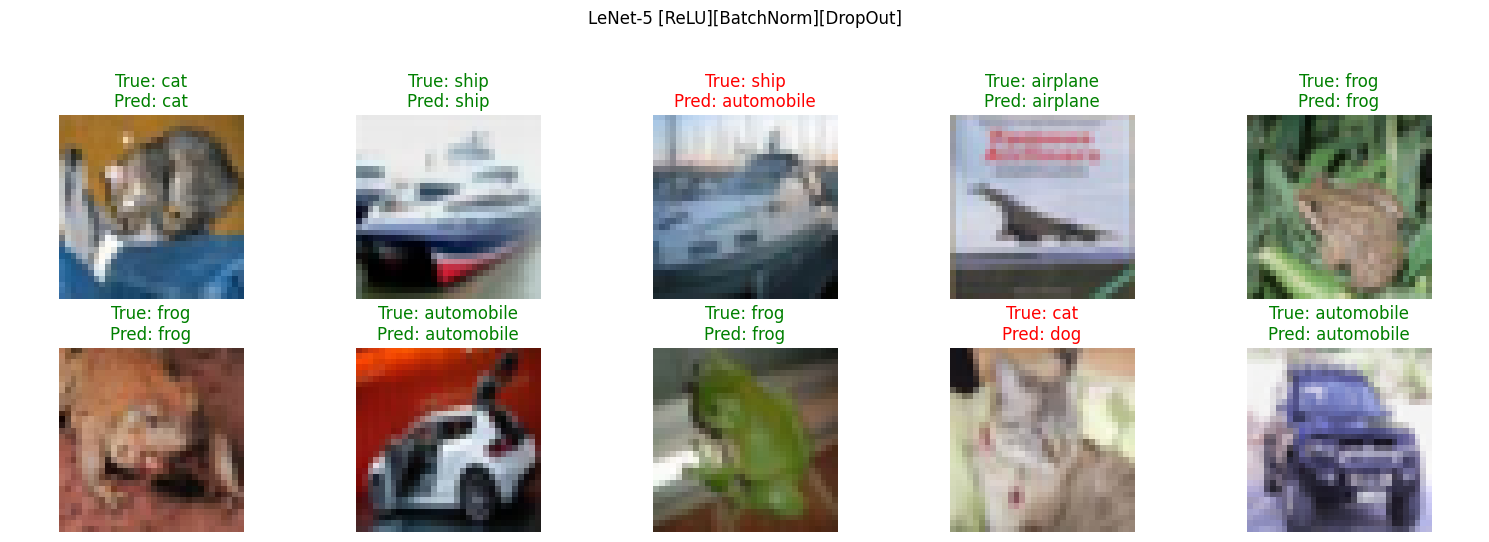

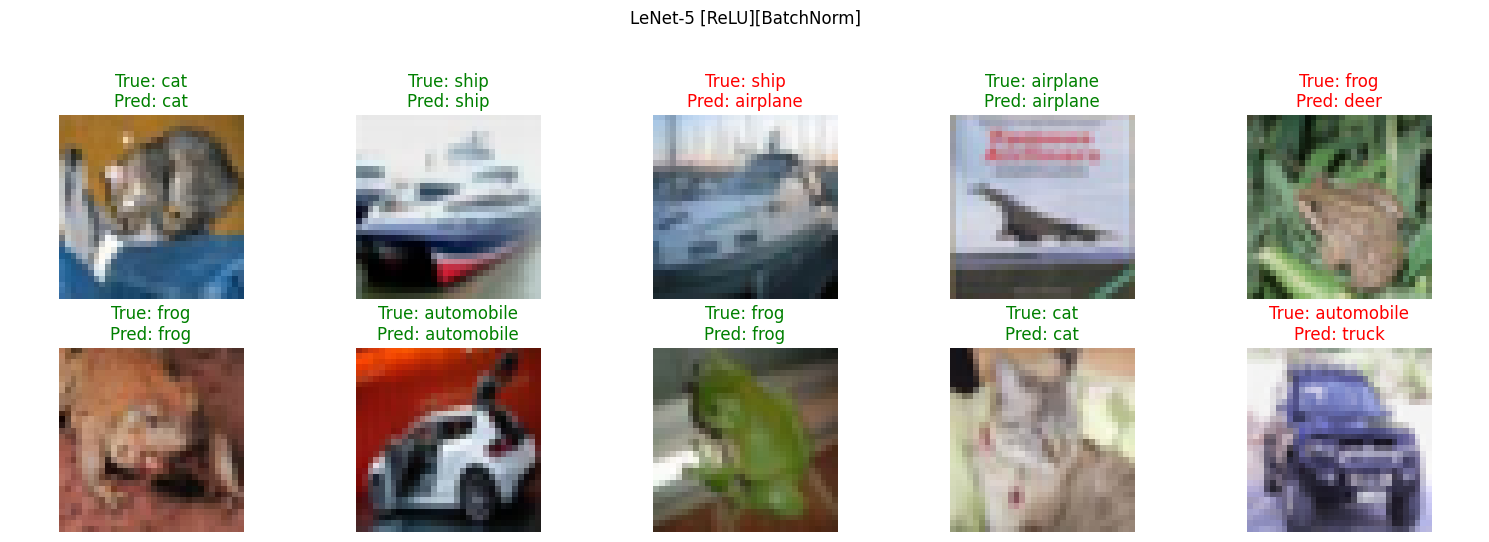

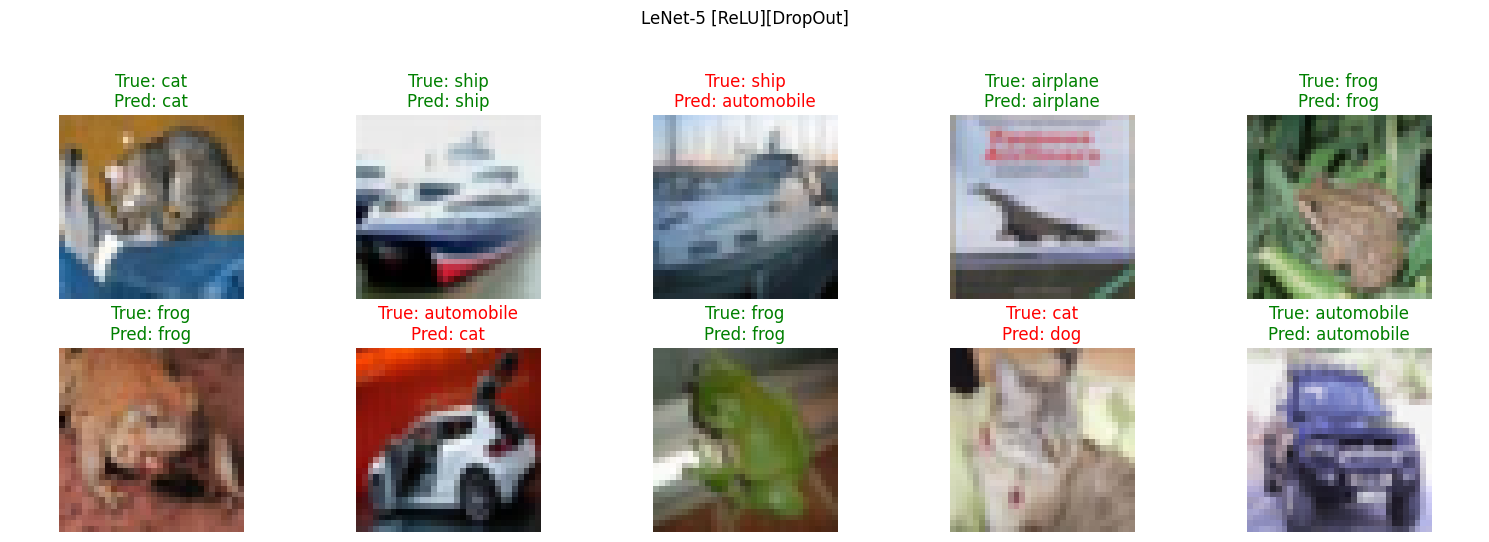

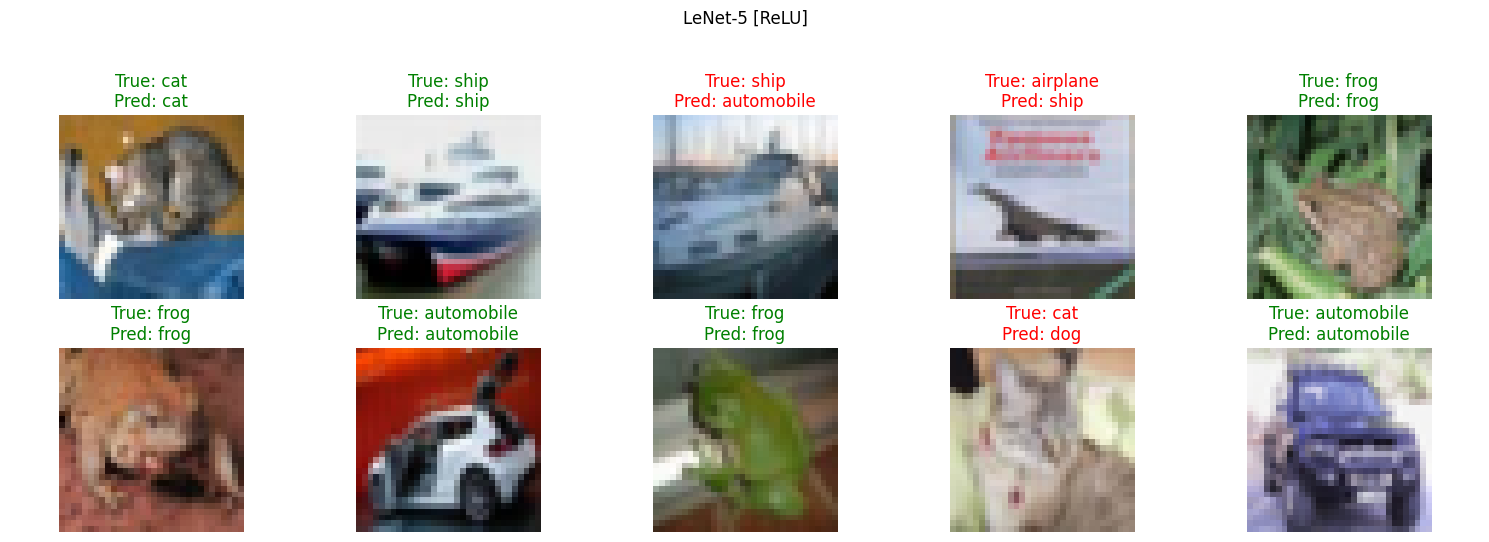

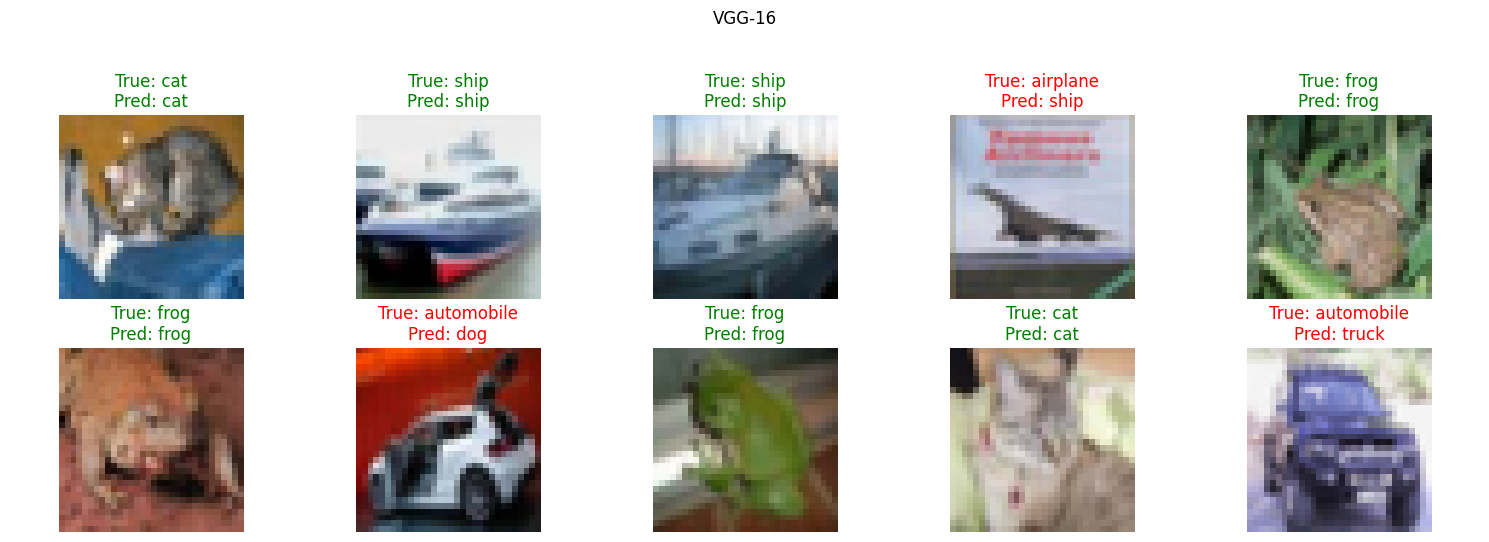

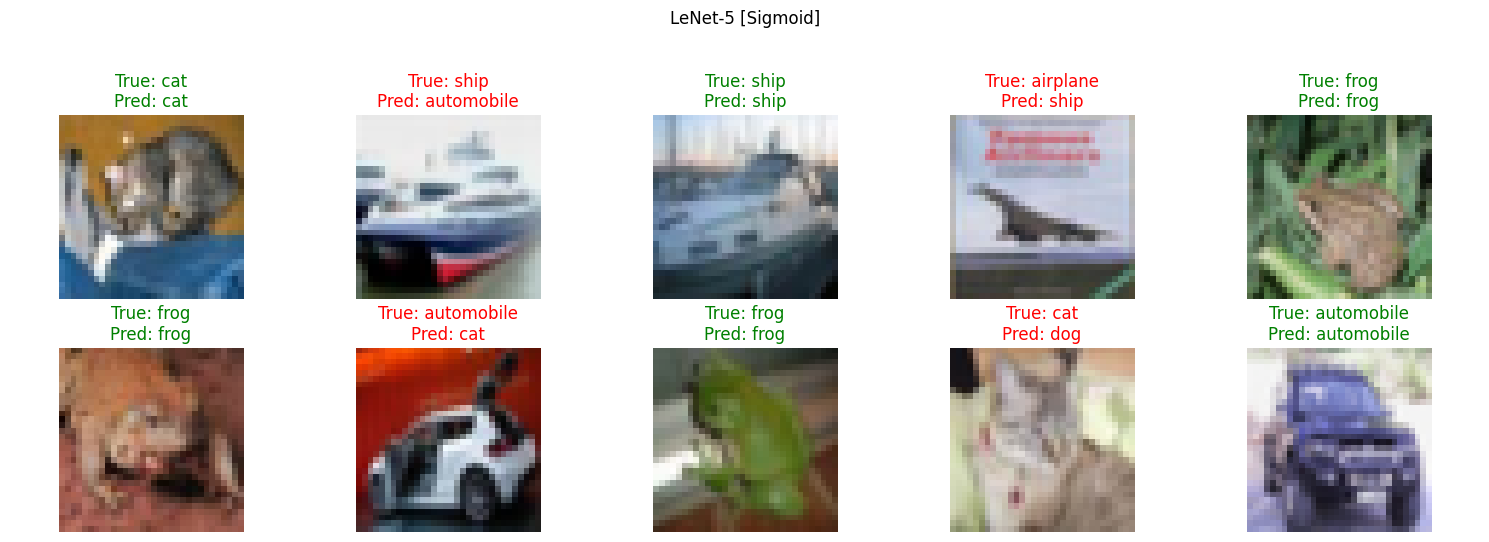

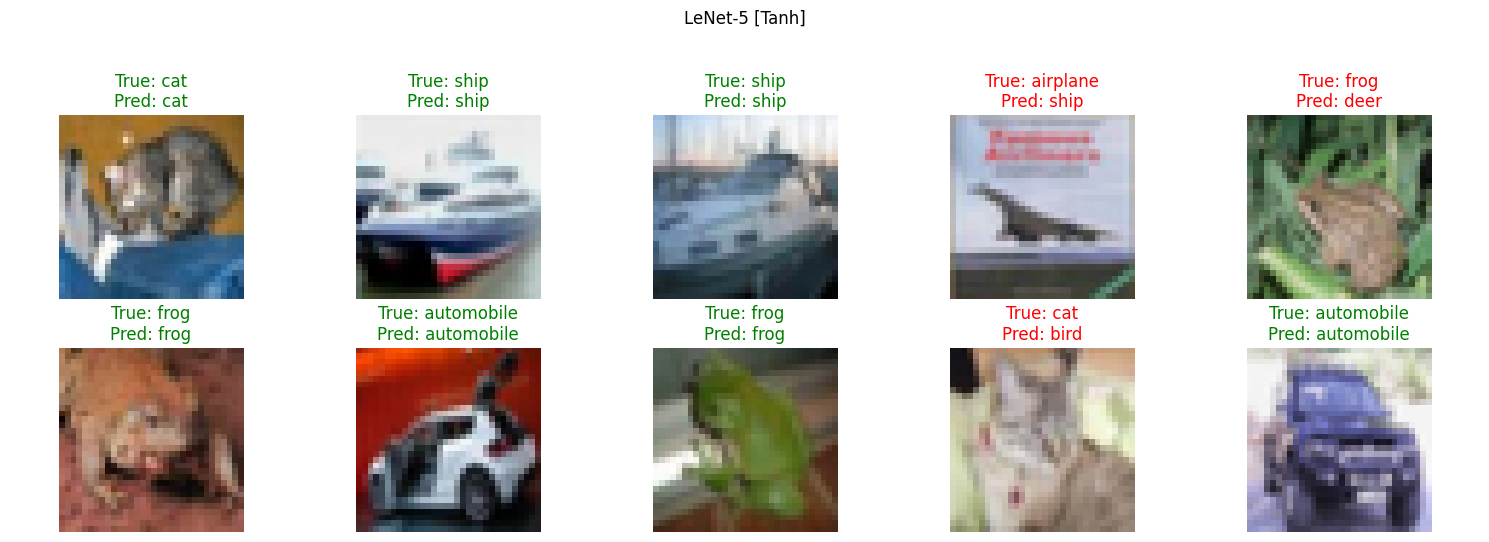

In [72]:
for name, model in models.items(): 
    model.eval()
    test_iter = iter(dm.test_dataloader())
    images, labels = next(test_iter)

    with torch.no_grad():
        #[Batch, 3, 32, 32]
        outputs = model(images)
        # [Batch]
        _, preds = torch.max(outputs, 1)

    class_names =['airplane', 'automobile', 'bird', 'cat', 'deer',
                'dog', 'frog', 'horse', 'ship', 'truck']

    def imshow(img):
        img = img * torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1) + torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
        npimg = img.numpy()
        return np.transpose(npimg, (1, 2, 0))
    plt.figure(figsize=(15, 6))
    plt.title(name, y = 1.2)
    plt.xticks([])
    plt.yticks([])
    plt.axis('off')
    for i in range(10):
        plt.subplot(2, 5, i+1)
        plt.imshow(np.clip(imshow(images[i]), 0, 1))
        title_color = 'green' if preds[i] == labels[i] else 'red'
        plt.title(f"True: {class_names[labels[i]]}\nPred: {class_names[preds[i]]}", color=title_color)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

## Задание 10. Оценка качества через Confusion Matrix
Построить матрицу ошибок для VGG.

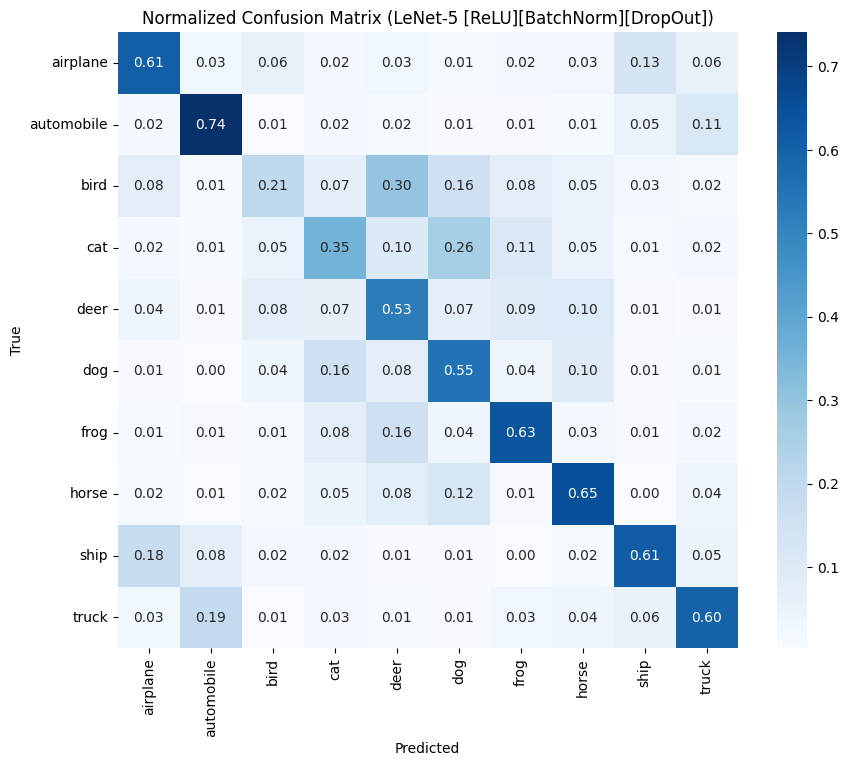


Classification Report:
              precision    recall  f1-score   support

    airplane       0.59      0.61      0.60      1000
  automobile       0.67      0.74      0.71      1000
        bird       0.42      0.21      0.28      1000
         cat       0.41      0.35      0.38      1000
        deer       0.40      0.53      0.45      1000
         dog       0.45      0.55      0.50      1000
        frog       0.62      0.63      0.63      1000
       horse       0.61      0.65      0.63      1000
        ship       0.66      0.61      0.64      1000
       truck       0.64      0.60      0.62      1000

    accuracy                           0.55     10000
   macro avg       0.55      0.55      0.54     10000
weighted avg       0.55      0.55      0.54     10000



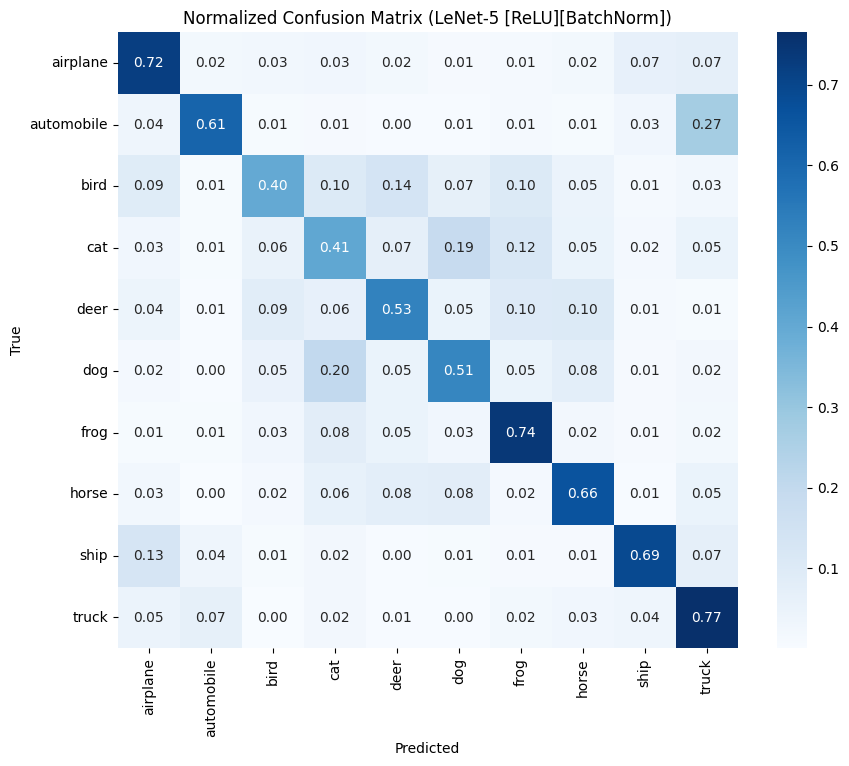


Classification Report:
              precision    recall  f1-score   support

    airplane       0.62      0.72      0.67      1000
  automobile       0.79      0.61      0.69      1000
        bird       0.59      0.40      0.47      1000
         cat       0.41      0.41      0.41      1000
        deer       0.56      0.53      0.54      1000
         dog       0.53      0.51      0.52      1000
        frog       0.62      0.74      0.68      1000
       horse       0.64      0.66      0.65      1000
        ship       0.77      0.69      0.73      1000
       truck       0.56      0.77      0.65      1000

    accuracy                           0.60     10000
   macro avg       0.61      0.60      0.60     10000
weighted avg       0.61      0.60      0.60     10000



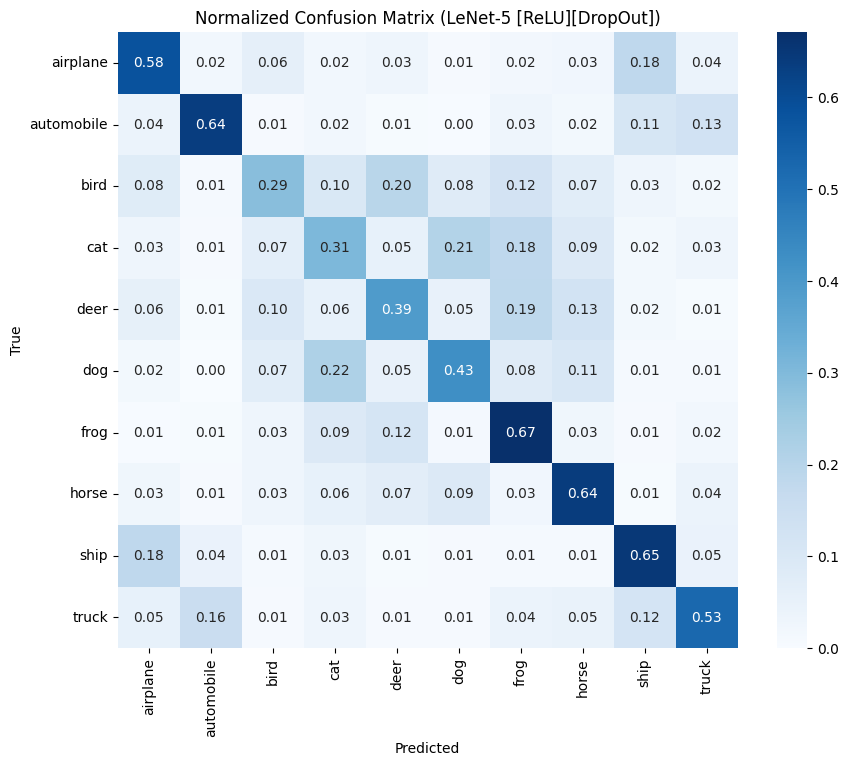


Classification Report:
              precision    recall  f1-score   support

    airplane       0.54      0.58      0.56      1000
  automobile       0.71      0.64      0.67      1000
        bird       0.42      0.29      0.34      1000
         cat       0.33      0.31      0.32      1000
        deer       0.42      0.39      0.40      1000
         dog       0.47      0.43      0.45      1000
        frog       0.49      0.67      0.57      1000
       horse       0.55      0.64      0.59      1000
        ship       0.56      0.65      0.60      1000
       truck       0.60      0.53      0.56      1000

    accuracy                           0.51     10000
   macro avg       0.51      0.51      0.51     10000
weighted avg       0.51      0.51      0.51     10000



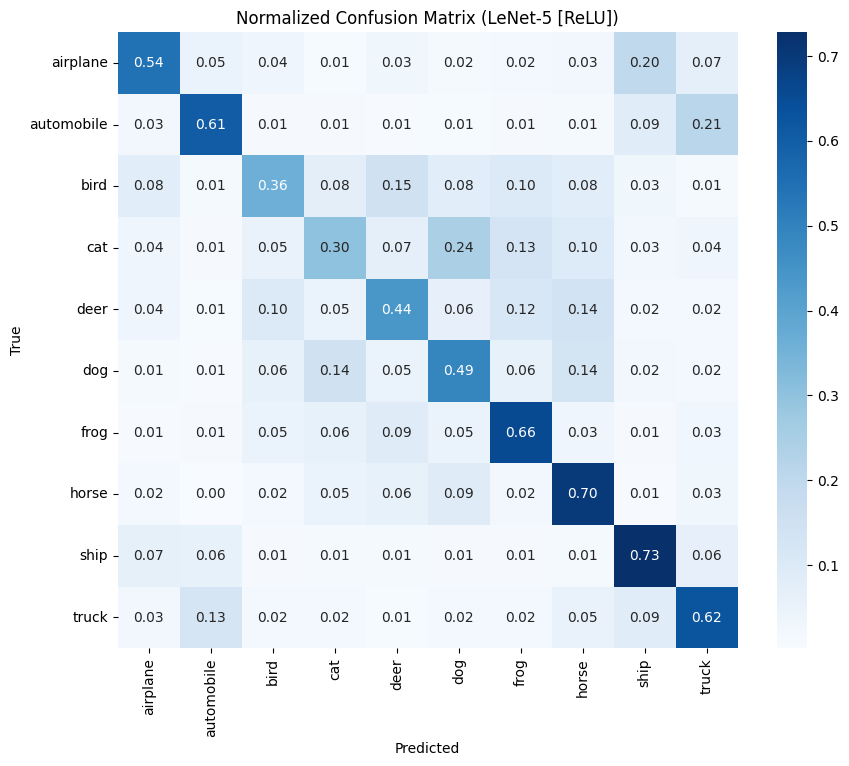


Classification Report:
              precision    recall  f1-score   support

    airplane       0.63      0.54      0.59      1000
  automobile       0.67      0.61      0.64      1000
        bird       0.50      0.36      0.42      1000
         cat       0.40      0.30      0.34      1000
        deer       0.48      0.44      0.46      1000
         dog       0.46      0.49      0.47      1000
        frog       0.57      0.66      0.61      1000
       horse       0.54      0.70      0.61      1000
        ship       0.60      0.73      0.66      1000
       truck       0.56      0.62      0.59      1000

    accuracy                           0.55     10000
   macro avg       0.54      0.54      0.54     10000
weighted avg       0.54      0.55      0.54     10000



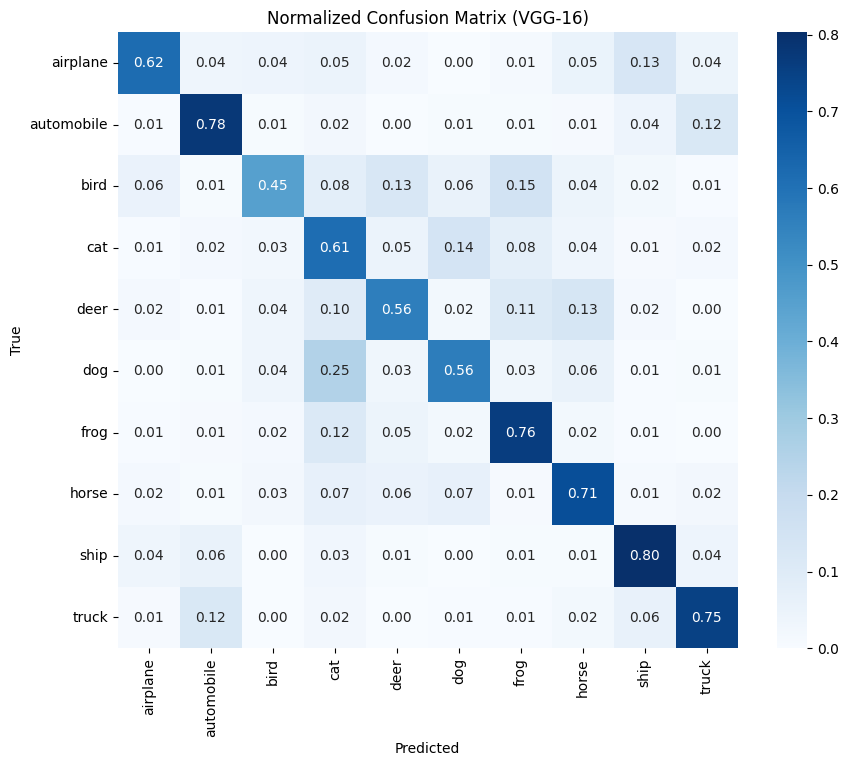


Classification Report:
              precision    recall  f1-score   support

    airplane       0.80      0.62      0.70      1000
  automobile       0.74      0.78      0.76      1000
        bird       0.70      0.45      0.55      1000
         cat       0.45      0.61      0.52      1000
        deer       0.63      0.56      0.59      1000
         dog       0.64      0.56      0.60      1000
        frog       0.65      0.76      0.70      1000
       horse       0.65      0.71      0.68      1000
        ship       0.72      0.80      0.76      1000
       truck       0.74      0.75      0.75      1000

    accuracy                           0.66     10000
   macro avg       0.67      0.66      0.66     10000
weighted avg       0.67      0.66      0.66     10000



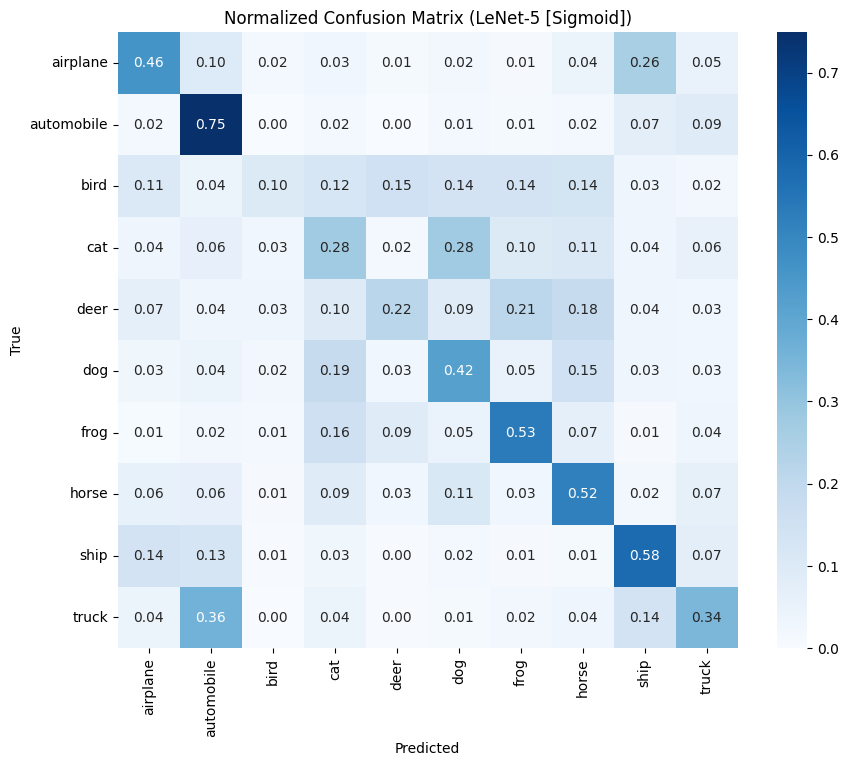


Classification Report:
              precision    recall  f1-score   support

    airplane       0.47      0.46      0.47      1000
  automobile       0.47      0.75      0.57      1000
        bird       0.44      0.10      0.17      1000
         cat       0.26      0.28      0.27      1000
        deer       0.39      0.22      0.28      1000
         dog       0.36      0.42      0.39      1000
        frog       0.47      0.53      0.50      1000
       horse       0.40      0.52      0.45      1000
        ship       0.47      0.58      0.52      1000
       truck       0.43      0.34      0.38      1000

    accuracy                           0.42     10000
   macro avg       0.42      0.42      0.40     10000
weighted avg       0.42      0.42      0.40     10000



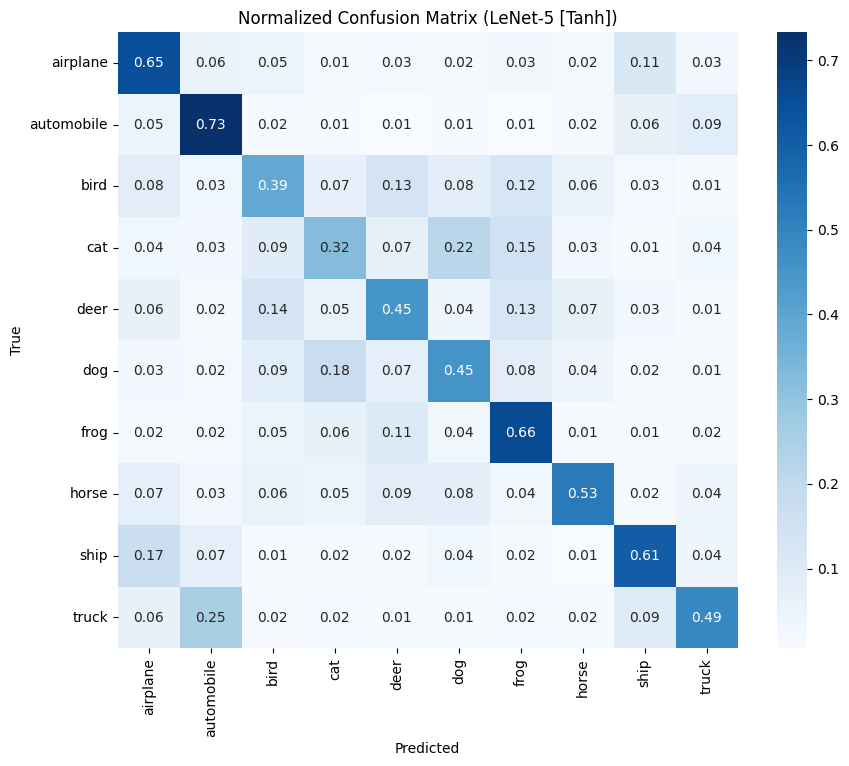


Classification Report:
              precision    recall  f1-score   support

    airplane       0.53      0.65      0.58      1000
  automobile       0.58      0.73      0.65      1000
        bird       0.43      0.39      0.41      1000
         cat       0.41      0.32      0.36      1000
        deer       0.46      0.45      0.45      1000
         dog       0.46      0.45      0.46      1000
        frog       0.52      0.66      0.58      1000
       horse       0.66      0.53      0.59      1000
        ship       0.61      0.61      0.61      1000
       truck       0.62      0.49      0.55      1000

    accuracy                           0.53     10000
   macro avg       0.53      0.53      0.52     10000
weighted avg       0.53      0.53      0.52     10000



In [73]:
test = dm.cifar_test
length = test.data.shape[0]
images = torch.tensor(torch.tensor(test.data).reshape(length, 3, 32, 32).numpy(), dtype=torch.float16)
labels = test.targets

for name, model in models.items(): 

    model.eval()
    model.to('cuda')

    all_preds = []
    all_labels =[]

    with torch.no_grad():
        for images, labels in dm.test_dataloader():
            images = images.to('cuda')
            labels = labels.to('cuda')

            with torch.autocast(device_type='cuda', dtype=torch.float16):
                # [Batch_size, 10]
                outputs = model(images)
                
            #[Batch_size]
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    class_names =['airplane', 'automobile', 'bird', 'cat', 'deer',
                'dog', 'frog', 'horse', 'ship', 'truck']

    cm = confusion_matrix(all_labels, all_preds)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Normalized Confusion Matrix ({name})')
    plt.show()

    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

## Задание 11. Поиск гиперпараметров
Использовать GridSearch для оптимизации learning rate, числа фильтров. Используйте Keras Tuner

Если честно, я не сильно понял, для какой модели мы хотим провести оптимизацию, так чтоя сделал, что сделал.

In [74]:
class TunableCNN(pl.LightningModule):
    def __init__(self, conv1_filters: int, lr: float):
        super().__init__()
        self.save_hyperparameters()
        self.lr = lr
        
        self.conv1 = nn.Conv2d(3, conv1_filters, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc = nn.Linear(conv1_filters * 16 * 16, 10)
        
        self.val_acc = torchmetrics.Accuracy(task="multiclass", num_classes=10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

    def training_step(self, batch, batch_idx):
        x, y = batch
        loss = F.cross_entropy(self(x), y)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        self.val_acc(logits, y)
        self.log('val_acc', self.val_acc, prog_bar=True)

    def configure_optimizers(self):
        return optim.Adam(self.parameters(), lr=self.lr)

def objective(trial):
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    conv1_filters = trial.suggest_categorical("conv1_filters", [16, 32, 64])
    
    model = TunableCNN(conv1_filters=conv1_filters, lr=lr)
    
    trainer = pl.Trainer(
        max_epochs=2,
        accelerator='auto',
        enable_progress_bar=False,
        logger=False,
        enable_checkpointing=False
    )
    
    trainer.fit(model, datamodule=dm)
    
    val_res = trainer.validate(model, datamodule=dm, verbose=False)
    return val_res[0]['val_acc']

print("Запускаем Optuna Study...")
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=3)

print(f"Лучшая точность (Validation Accuracy): {study.best_value:.4f}")
print("Лучшие гиперпараметры:")
for key, value in study.best_params.items():
    print(f" - {key}: {value}")

[I 2026-03-29 00:50:55,784] A new study created in memory with name: no-name-55f482a6-9c84-4866-af15-6934b4d48f48
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Запускаем Optuna Study...


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ conv1   │ Conv2d             │    448 │ train │     0 │
│ 1 │ pool    │ MaxPool2d          │      0 │ train │     0 │
│ 2 │ fc      │ Linear             │ 41.0 K │ train │     0 │
│ 3 │ val_acc │ MulticlassAccuracy │      0 │ train │     0 │
└───┴─────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 41.4 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 41.4 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 4                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

`Trainer.fit` stopped: `max_epochs=2` reached.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
[I 2026-03-29 00:52:55,450] Trial 1 finished with value: 0.5108000040054321 and parameters: {'lr': 0.00023078958497032667, 'conv1_filters': 16}. Best is trial 0 with value: 0.6014000177383423.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ conv1   │ Conv2d             │    448 │ train │     0 │
│ 1 │ pool    │ MaxPool2d          │      0 │ train │     0 │
│ 2 │ fc      │ Linear             │ 41.0 K │ train │     0 │
│ 3 │ val_acc │ MulticlassAccuracy │      0 │ train │     0 │
└───┴─────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 41.4 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 41.4 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 4                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

`Trainer.fit` stopped: `max_epochs=2` reached.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
[I 2026-03-29 00:53:55,919] Trial 2 finished with value: 0.5756000280380249 and parameters: {'lr': 0.008218784304696991, 'conv1_filters': 16}. Best is trial 0 with value: 0.6014000177383423.


Лучшая точность (Validation Accuracy): 0.6014
Лучшие гиперпараметры:
 - lr: 0.0045811153488308975
 - conv1_filters: 16
